### <center> Построение SIR-модели развития эпидемии в стране <center>

In [908]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

pd.options.display.float_format = '{:.0f}'.format

In [878]:


plt.rcParams.update({

    'figure.figsize': (20, 7),
    'figure.dpi': 120,

    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,

    'axes.facecolor': '#FAFAFA',
    'figure.facecolor': '#FFFFFF',
    'axes.edgecolor': '#DDDDDD',

    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '-',

    'lines.linewidth': 2.2,
    'lines.color': '#CDB4DB', 

    'legend.frameon': False,

    'axes.spines.top': False,
    'axes.spines.right': False,

    'axes.prop_cycle': plt.cycler(color=[
        '#A7C7E7',  
        '#B5EAD7',  
        '#FFDAC1',  
        '#FFB7B2',  
        '#CDB4DB'   
    ])
})

In [879]:
df = pd.read_excel('Мальдивы.xlsx')
df['Дата'] = pd.to_datetime(df['Дата'], format='%d.%m.%Y')
df = df.sort_values('Дата')
df.head()



,Страна,Дата,Заражений,Выздоровлений,Смертей,Заражений за день,Выздоровлений за день,Смертей за день,Население страны,Тестов,Тестов за день
0,Мальдивы,2020-07-20,2999,2369,15,33,7,0,393500,68696,711
1,Мальдивы,2020-07-21,3044,2397,15,45,28,0,393500,69370,674
2,Мальдивы,2020-07-22,3103,2397,15,59,0,0,393500,70050,680
3,Мальдивы,2020-07-23,3120,2428,15,17,31,0,393500,70845,795
4,Мальдивы,2020-07-24,3175,2498,15,55,70,0,393500,71974,1129


In [880]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Страна                 609 non-null    object        
 1   Дата                   609 non-null    datetime64[ns]
 2   Заражений              609 non-null    int64         
 3   Выздоровлений          381 non-null    float64       
 4   Смертей                609 non-null    int64         
 5   Заражений за день      609 non-null    int64         
 6   Выздоровлений за день  381 non-null    float64       
 7   Смертей за день        609 non-null    int64         
 8   Население страны       609 non-null    int64         
 9   Тестов                 609 non-null    int64         
 10  Тестов за день         609 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(7), object(1)
memory usage: 52.5+ KB


In [881]:
df[df['Выздоровлений'].isnull()]

,Страна,Дата,Заражений,Выздоровлений,Смертей,Заражений за день,Выздоровлений за день,Смертей за день,Население страны,Тестов,Тестов за день
381,Мальдивы,2021-08-05,77999,NaN,222,104,NaN,0,393500,1236636,5198
382,Мальдивы,2021-08-06,78130,NaN,222,131,NaN,0,393500,1242628,5992
383,Мальдивы,2021-08-07,78243,NaN,222,113,NaN,0,393500,1248292,5664
384,Мальдивы,2021-08-08,78356,NaN,222,113,NaN,0,393500,1255495,7203
385,Мальдивы,2021-08-09,78464,NaN,222,108,NaN,0,393500,1260796,5301
...,...,...,...,...,...,...,...,...,...,...,...
604,Мальдивы,2022-03-16,174658,NaN,297,0,NaN,0,393500,0,0
605,Мальдивы,2022-03-17,174658,NaN,297,0,NaN,0,393500,0,0
606,Мальдивы,2022-03-18,174658,NaN,297,0,NaN,0,393500,0,0
607,Мальдивы,2022-03-19,174658,NaN,297,0,NaN,0,393500,0,0


In [882]:
df['group'] = (df['Выздоровлений'].isna() != df['Выздоровлений'].isna().shift()).cumsum() 

missing_blocks = df[df['Выздоровлений'].isna()].groupby('group')['Дата'].agg(['min', 'max'])

print(missing_blocks) #идут ли пропуски подряд(группы пропусков)


             min        max
group                      
2     2021-08-05 2022-03-20


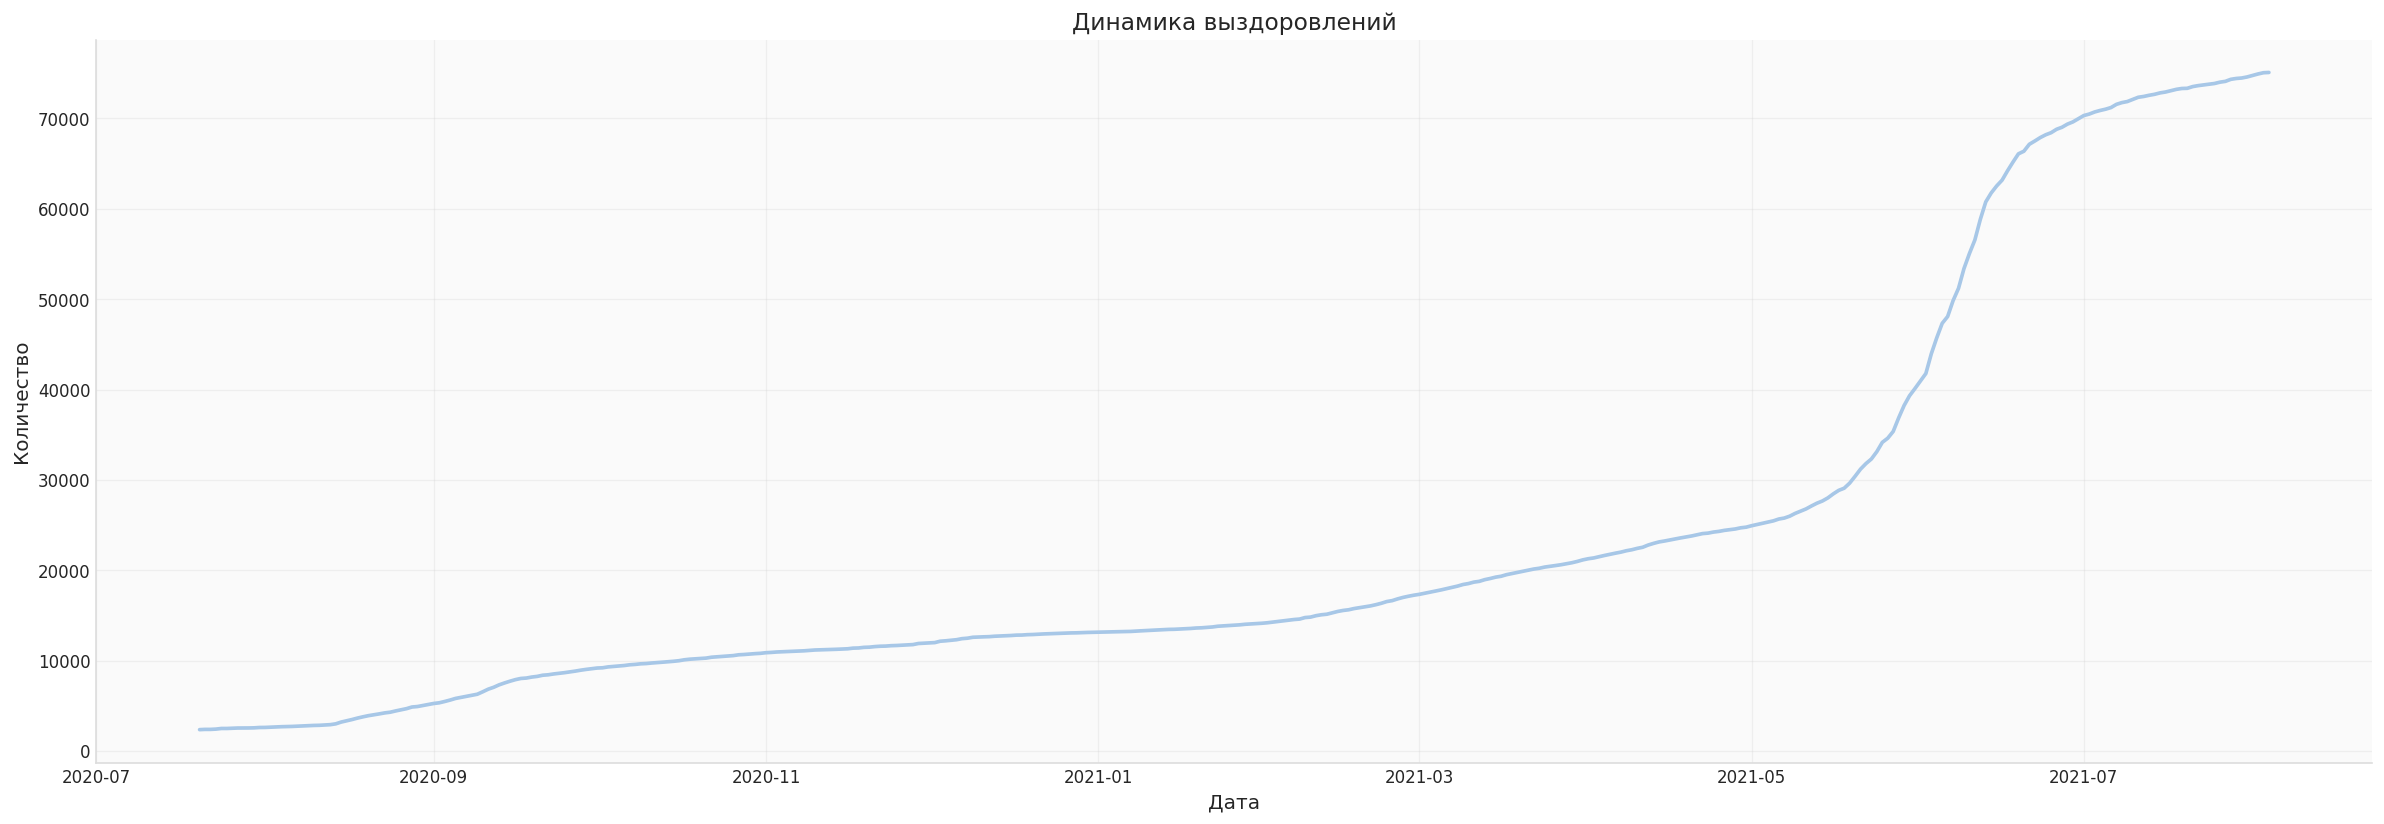

In [883]:


plt.figure()

plt.plot(df['Дата'], df['Выздоровлений'])

plt.title('Динамика выздоровлений')
plt.xlabel('Дата')
plt.ylabel('Количество')


plt.tight_layout()
plt.show()

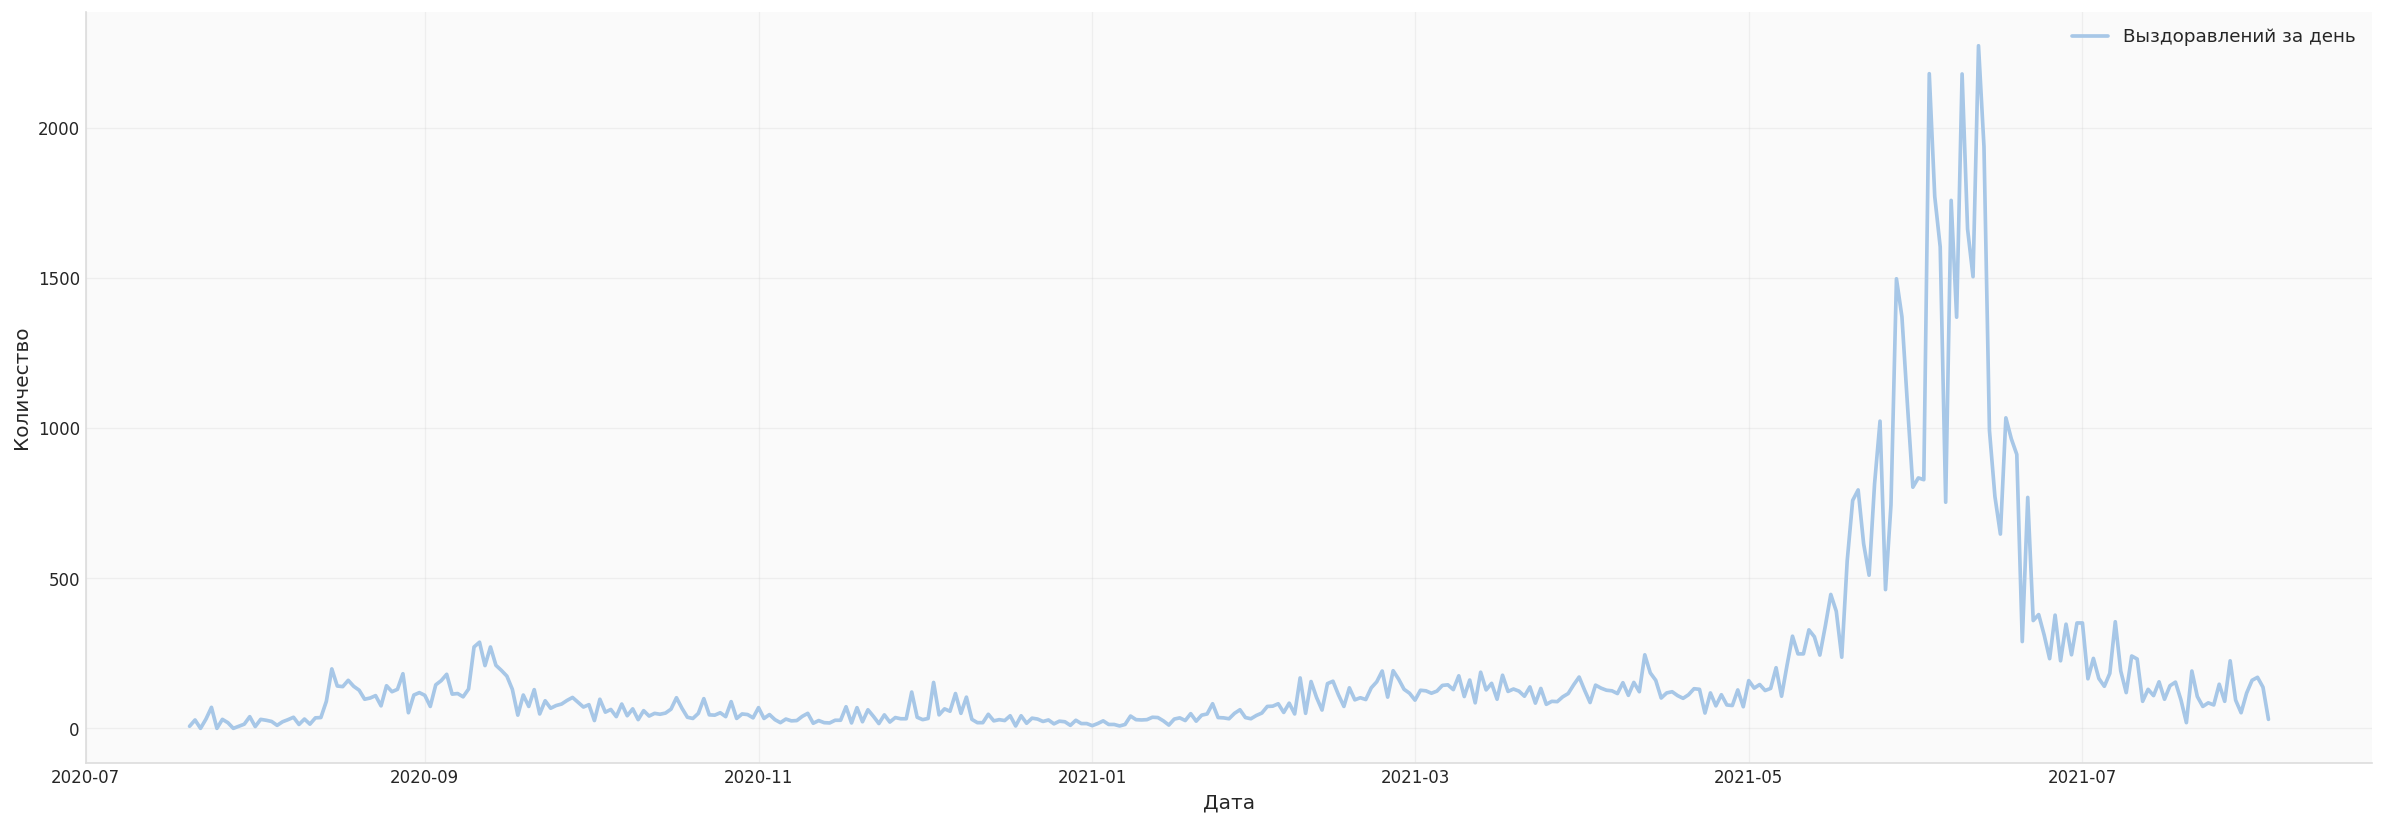

In [884]:
plt.figure()
plt.plot(df['Дата'], df['Выздоровлений за день'], label = 'Выздоравлений за день')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()




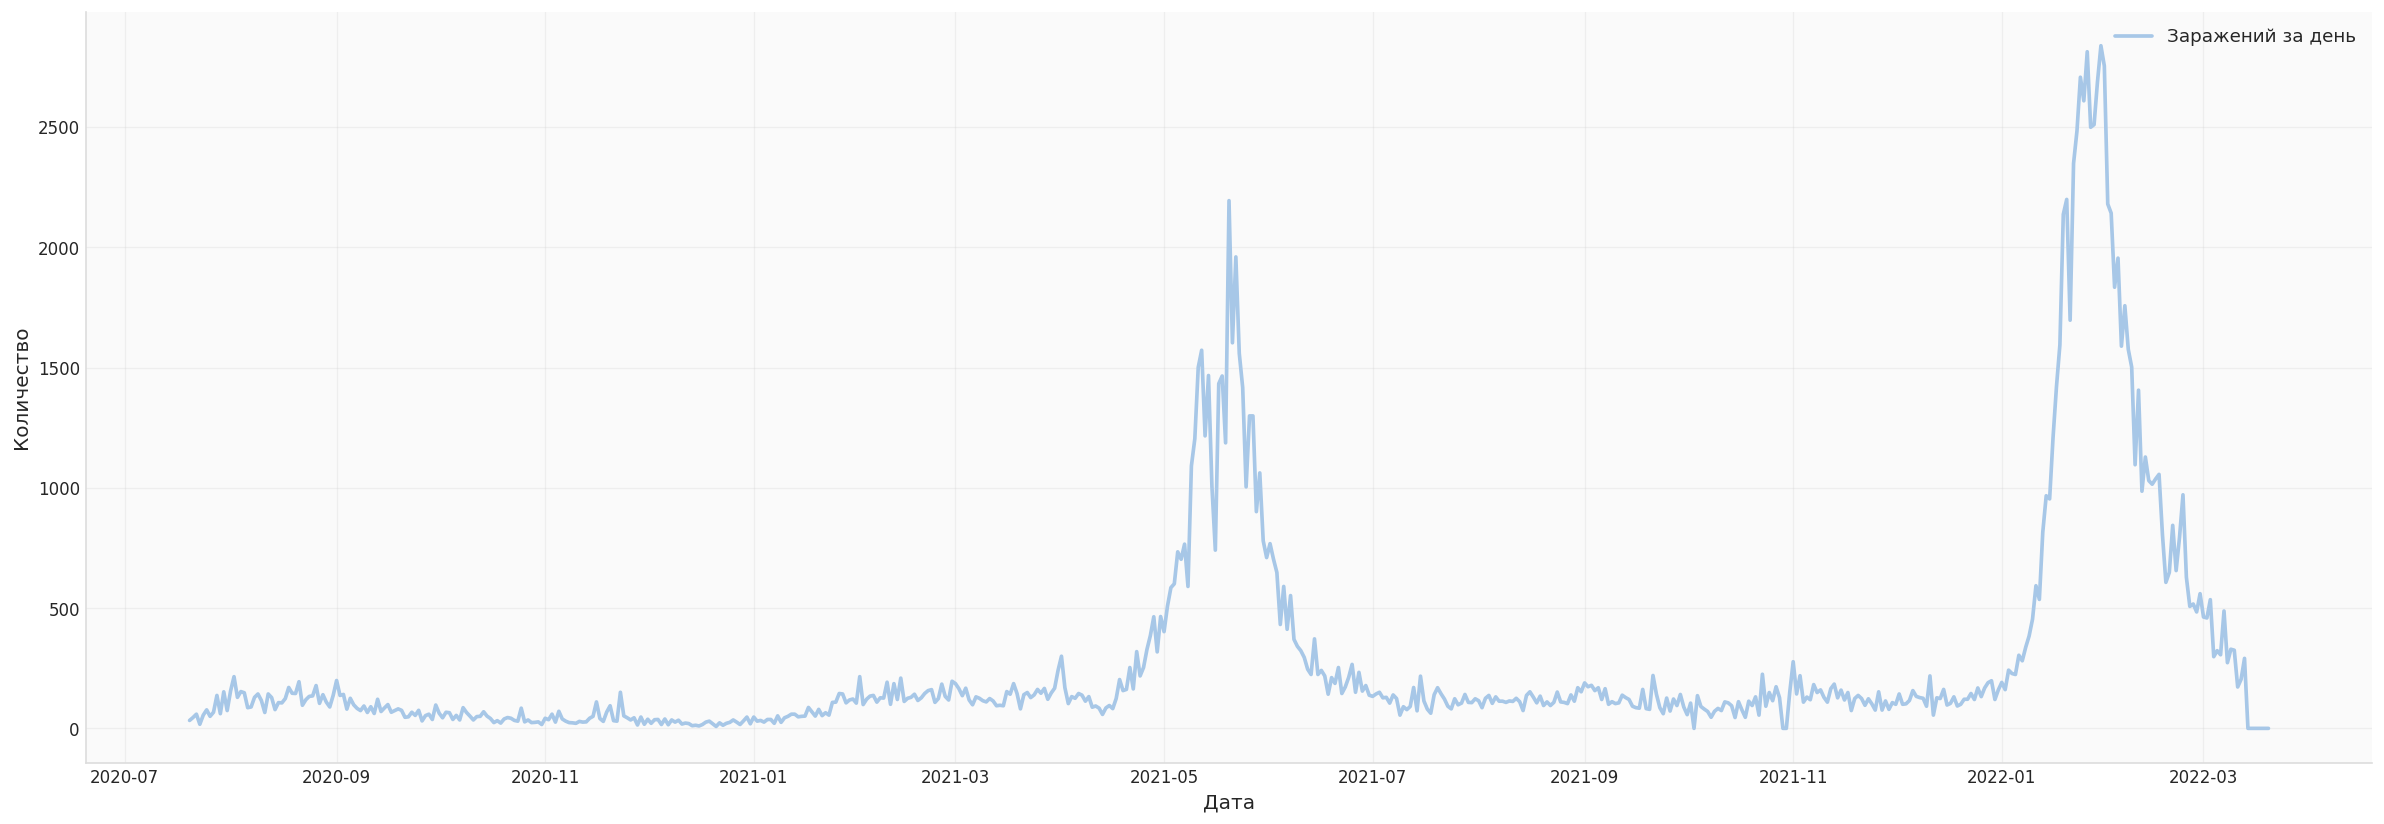

In [885]:
plt.figure()
plt.plot(df['Дата'], df['Заражений за день'], label = 'Заражений за день')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

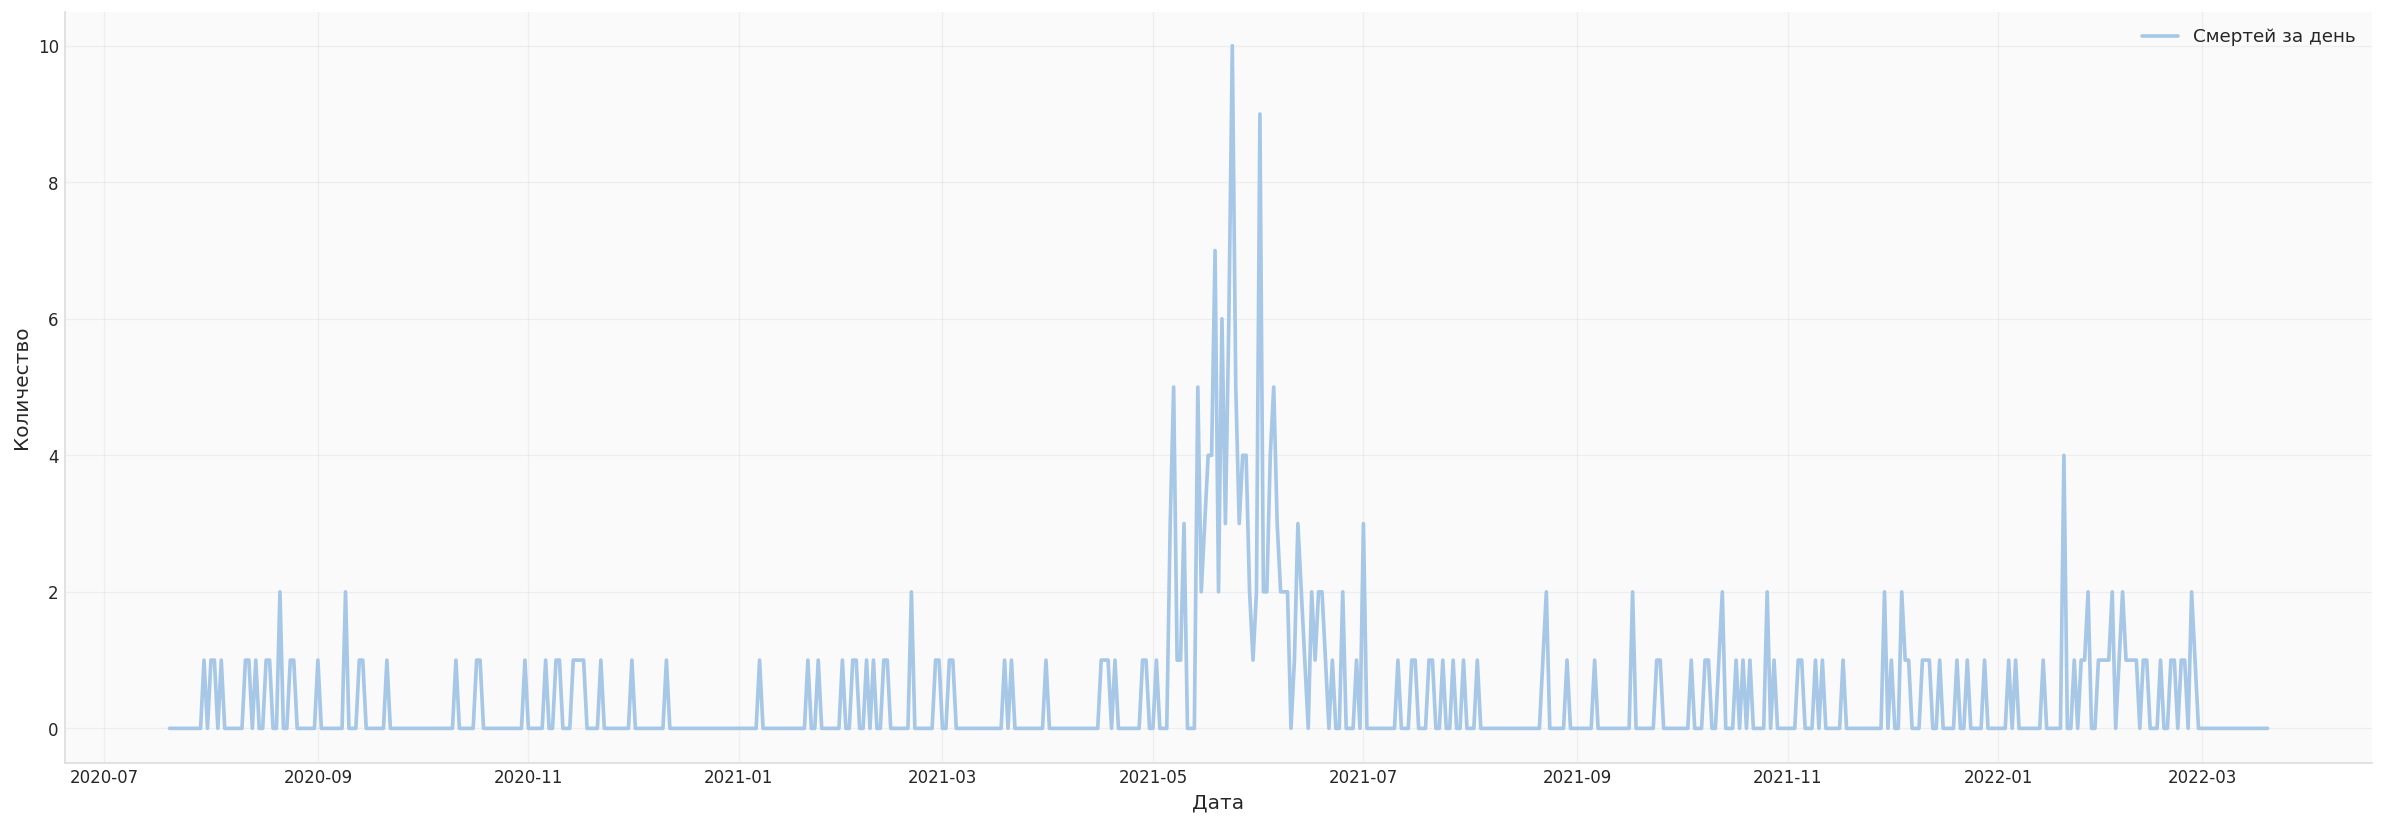

In [886]:
plt.figure()
plt.plot(df['Дата'], df['Смертей за день'], label = 'Смертей за день')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

Видим, что пропуски идут подряд и нет точек для интерполяции. Чтобы заполнить пропуски в столбцах "Выздоровлений" и "Выздоровлений за день" предскажем значения столбца "Выздоровлений за день" с помошью линейной регрессии, затем накопленный показатель «Выздоровлений» восстановим как сумма предыдущего значения и рассчитанного дневного прироста.

In [887]:
df_model = pd.DataFrame({
    'date': df['Дата'],
    'cases': df['Заражений за день'],
    'recoveries': df['Выздоровлений за день'],
    'deaths': df['Смертей за день']

})


df_model['cases_lag_7'] = df['Заражений за день'].shift(7) #создаем признаки
df_model['cases_lag_14'] = df['Заражений за день'].shift(14)
df_model['cases_lag_30'] = df['Заражений за день'].shift(30)
df_model['rec_lag_7'] = df['Выздоровлений за день'].shift(7)
df_model['rec_lag_14'] = df['Выздоровлений за день'].shift(14)
df_model['rec_lag_30'] = df['Выздоровлений за день'].shift(30)
df_model['deaths_lag_7'] = df['Смертей за день'].shift(7)
df_model['deaths_lag_14'] = df['Смертей за день'].shift(14)
df_model['deaths_lag_30'] = df['Смертей за день'].shift(30)


df_model = df_model.dropna()

In [888]:
y = df_model['recoveries']
X = df_model.drop(columns=['recoveries', 'date'])
X.head()

,cases,deaths,cases_lag_7,cases_lag_14,cases_lag_30,rec_lag_7,rec_lag_14,rec_lag_30,deaths_lag_7,deaths_lag_14,deaths_lag_30
30,146,0,143,148,33,35,10,7,1,0,0
31,145,0,128,86,45,36,22,28,0,0,0
32,194,2,78,89,59,90,29,0,1,0,0
33,96,0,107,129,17,198,37,31,0,0,0
34,119,0,106,143,55,141,13,70,0,0,0


In [889]:
split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]


model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [890]:
y_pred = model.predict(X_test)

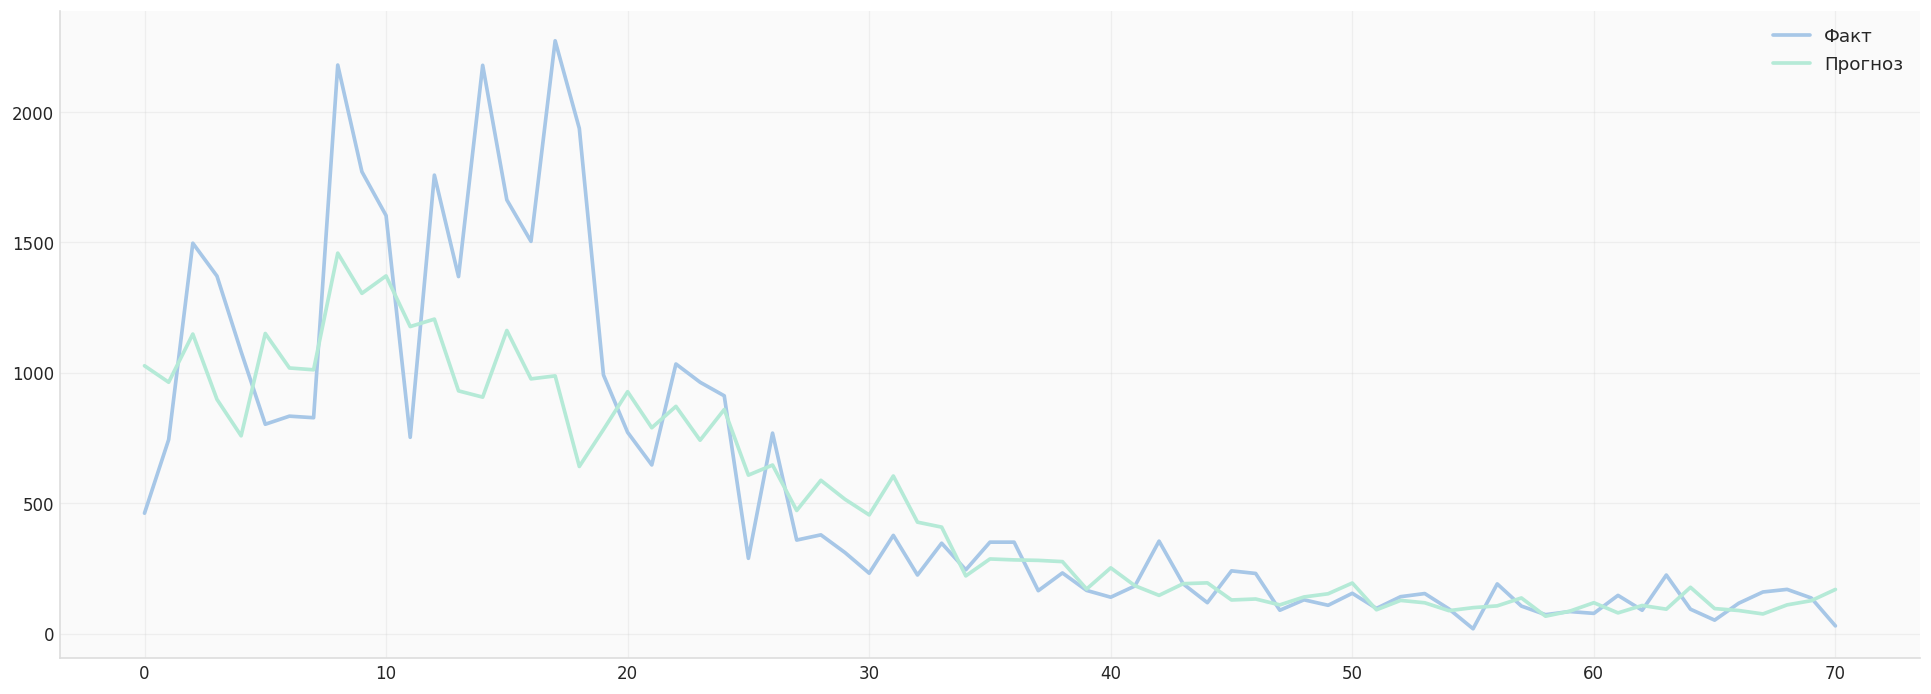

In [891]:

plt.plot(y_test.values, label='Факт')
plt.plot(y_pred, label='Прогноз') #тестируем модель 

plt.legend()
plt.show()

In [892]:
y = df_model['recoveries']
X = df_model.drop(columns=['recoveries', 'date']) #Обучаем на всех данных

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [893]:
df_model = pd.DataFrame({
    'date': df['Дата'],
    'cases': df['Заражений за день'],
    'recoveries': df['Выздоровлений за день'],
    'deaths': df['Смертей за день']
})


df_model['cases_lag_7'] = df['Заражений за день'].shift(7)
df_model['cases_lag_14'] = df['Заражений за день'].shift(14)
df_model['cases_lag_30'] = df['Заражений за день'].shift(30)
df_model['rec_lag_7'] = df['Выздоровлений за день'].shift(7)
df_model['rec_lag_14'] = df['Выздоровлений за день'].shift(14)
df_model['rec_lag_30'] = df['Выздоровлений за день'].shift(30)
df_model['deaths_lag_7'] = df['Смертей за день'].shift(7)
df_model['deaths_lag_14'] = df['Смертей за день'].shift(14)
df_model['deaths_lag_30'] = df['Смертей за день'].shift(30)

# df_model = df_model[30:]

df_model = df_model.dropna(subset=['cases']).reset_index(drop=True)
df_model = df_model.dropna(subset=['deaths']).reset_index(drop=True)

y_pred = df_model['recoveries'].copy()
X_pred = df_model.drop(columns=['recoveries', 'date'])


size = df_model['recoveries'].isna().to_numpy().argmax()
print(size)
#рекуррсивно предсказываем 
for i in range(size, len(df_model), 7 ):

    X_pred_7 = X_pred[i:i+7]
    y_pred[i:i+7] = model.predict(X_pred_7)
    for j in range(i+7, i+14):
        if j < len(df_model):
            if j >= 7:
                X_pred.loc[j, 'rec_lag_7'] = y_pred[j-7]
            if j >= 14:
                X_pred.loc[j, 'rec_lag_14'] = y_pred[j-14]
            if j >= 30:
                X_pred.loc[j, 'rec_lag_30'] = y_pred[j-30]


381


In [894]:
df['Выздоровлений за день'] = y_pred

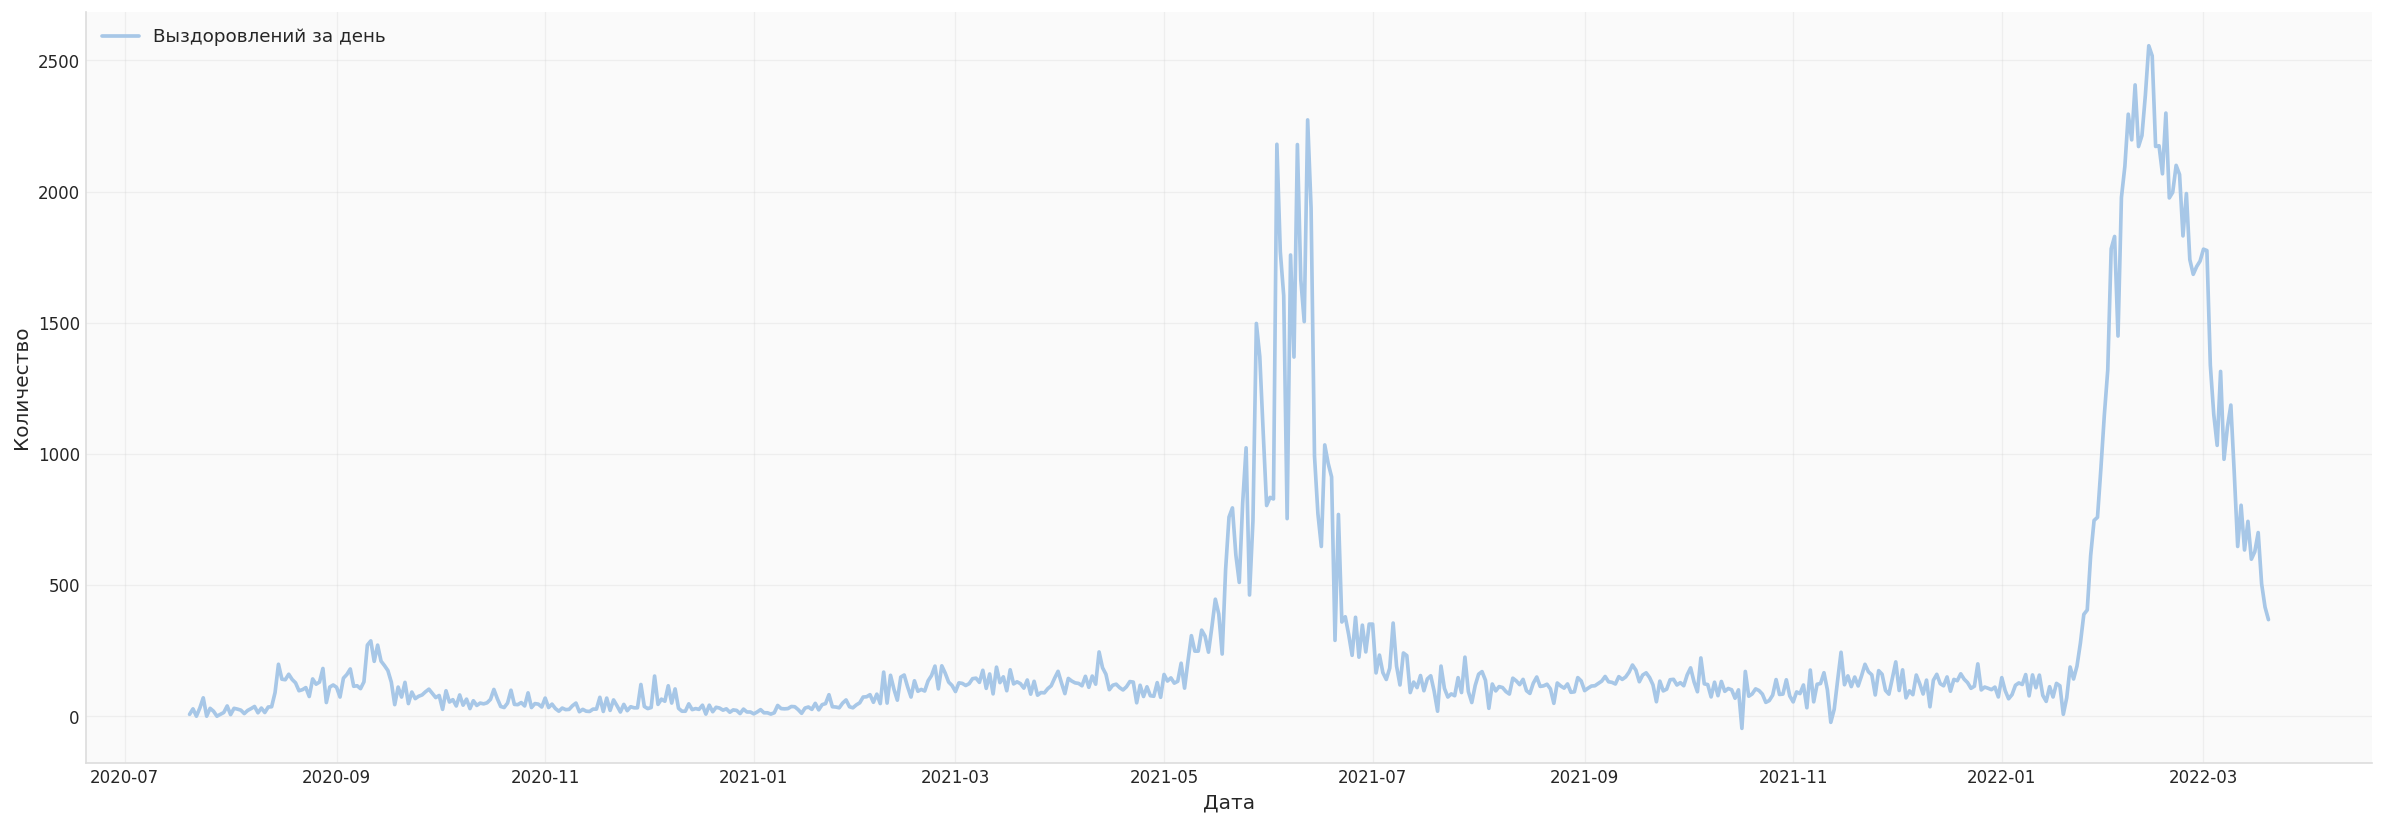

In [895]:
plt.figure()
plt.plot(df['Дата'], df['Выздоровлений за день'], label = 'Выздоровлений за день')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

In [896]:
for i in range(len(df)):

    if pd.isna(df.loc[i, 'Выздоровлений']):
        df.loc[i, 'Выздоровлений'] = (
            df.loc[i-1, 'Выздоровлений'] +
            df.loc[i, 'Выздоровлений за день']
        )

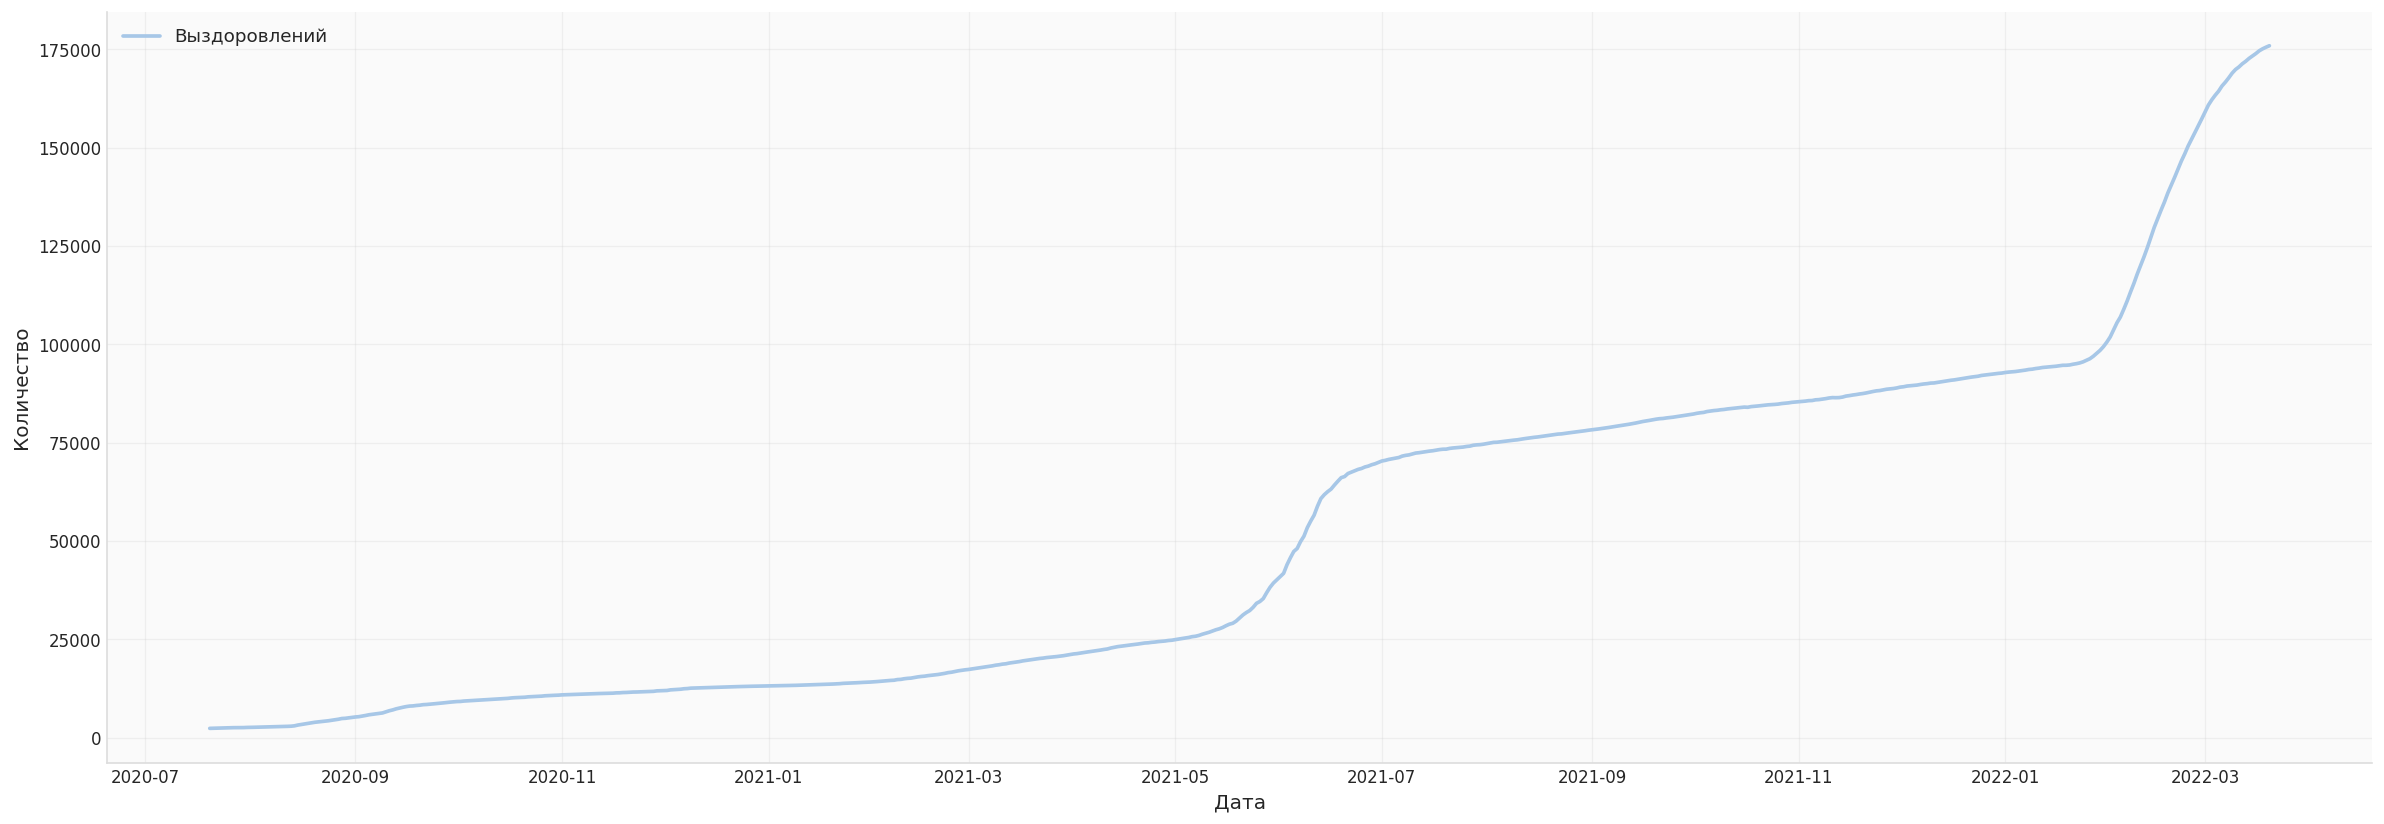

In [897]:
plt.figure()
plt.plot(df['Дата'], df['Выздоровлений'], label = 'Выздоровлений')

plt.legend()
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.xticks()
plt.tight_layout()
plt.show()

### <center> Вычисление количества инфицированных <center>




In [898]:
df['Количество инфицированных'] = df['Заражений'] - df['Выздоровлений'] - df['Смертей']

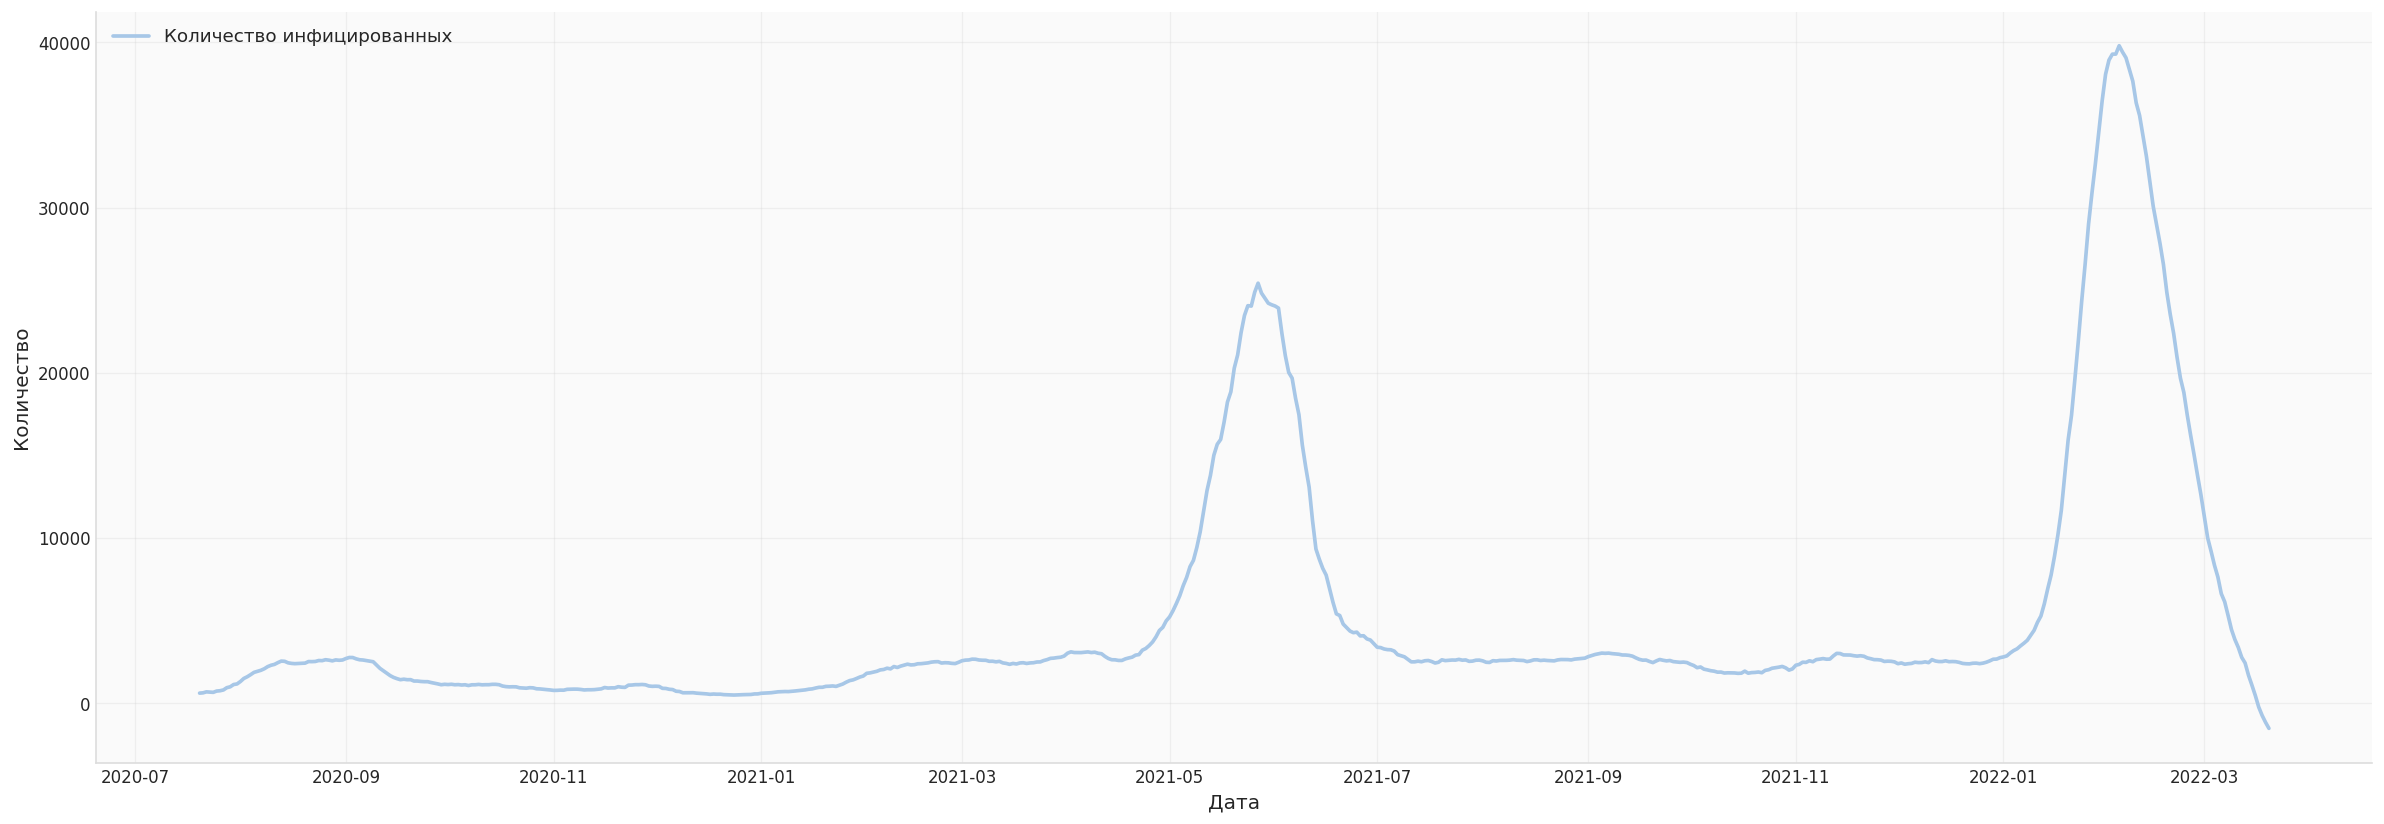

In [899]:
plt.figure()
plt.plot(df['Дата'], df['Количество инфицированных'], label = 'Количество инфицированных')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.xticks() 
plt.tight_layout()
plt.show()

In [900]:
df.iloc[-5:]

,Страна,Дата,Заражений,Выздоровлений,Смертей,Заражений за день,Выздоровлений за день,Смертей за день,Население страны,Тестов,Тестов за день,group,Количество инфицированных
604,Мальдивы,2022-03-16,174658,173891,297,0,627,0,393500,0,0,2,470
605,Мальдивы,2022-03-17,174658,174591,297,0,700,0,393500,0,0,2,-230
606,Мальдивы,2022-03-18,174658,175095,297,0,505,0,393500,0,0,2,-734
607,Мальдивы,2022-03-19,174658,175511,297,0,416,0,393500,0,0,2,-1150
608,Мальдивы,2022-03-20,174658,175879,297,0,368,0,393500,0,0,2,-1518


<center>Нормировка данных на 100 тыс. человек <center>

In [901]:
df['Заражений_на_100к'] = df['Заражений'] / df['Население страны'] * 100000
df['Выздоровлений_на_100к'] = df['Выздоровлений'] / df['Население страны'] * 100000
df['Смертей_на_100к'] = df['Смертей'] / df['Население страны'] * 100000
df['Инфицированных_на_100к'] = df['Количество инфицированных'] / df['Население страны'] * 100000
df['Выздоровлений_за_день_на_100к'] = df['Выздоровлений за день'] / df['Население страны'] * 100000
df['Заражений_за_день_на_100к'] = df['Заражений за день'] / df['Население страны'] * 100000

In [902]:
df.iloc[-5:]

,Страна,Дата,Заражений,Выздоровлений,Смертей,Заражений за день,Выздоровлений за день,Смертей за день,Население страны,Тестов,Тестов за день,group,Количество инфицированных,Заражений_на_100к,Выздоровлений_на_100к,Смертей_на_100к,Инфицированных_на_100к,Выздоровлений_за_день_на_100к,Заражений_за_день_на_100к
604,Мальдивы,2022-03-16,174658,173891,297,0,627,0,393500,0,0,2,470,44386,44191,75,119,159,0
605,Мальдивы,2022-03-17,174658,174591,297,0,700,0,393500,0,0,2,-230,44386,44369,75,-58,178,0
606,Мальдивы,2022-03-18,174658,175095,297,0,505,0,393500,0,0,2,-734,44386,44497,75,-187,128,0
607,Мальдивы,2022-03-19,174658,175511,297,0,416,0,393500,0,0,2,-1150,44386,44603,75,-292,106,0
608,Мальдивы,2022-03-20,174658,175879,297,0,368,0,393500,0,0,2,-1518,44386,44696,75,-386,94,0


 <center>
 
### Оценка параметра $\gamma$. Оценка средней продолжительности заболевания 


In [903]:
gamma = 0
ch =0 
zn = 0
for i in range(len(df)):
    ch += df.loc[i, 'Выздоровлений_за_день_на_100к']*df.loc[i, 'Инфицированных_на_100к']
    zn += df.loc[i, 'Инфицированных_на_100к']**2

gamma = ch/zn
print('gamma = ', gamma)
print('Средняя продолжительность заболевания = ',  int(1/gamma), 'дней')

gamma =  0.05220467741056573
Средняя продолжительность заболевания =  19 дней


 <center>
 
### Оценка параметра $\beta$ методом наименьших квадратов


Пусть число новых заболевших за $n$-й:
$$
\nu_n = \beta \frac{S_n I_n}{N}
$$

Статистические данные обозначим через $\bar{\nu}_n$  

Оценка параметра $\beta$ методом наименьших квадратов определяется из условия:
$$
\sum_{n} (\bar{\nu}_n - \nu_n)^2 \rightarrow \min_{\beta}
$$

Подставим выражение для $\nu_n$:
$$
\sum_{n} \left(\bar{\nu}_n - \beta \frac{S_n I_n}{N} \right)^2 \rightarrow \min_{\beta}
$$

Найдём минимум, приравняв производную по $\beta$ к нулю:
$$
\frac{d}{d\beta} \sum_{n} \left(\bar{\nu}_n - \beta \frac{S_n I_n}{N} \right)^2 = 0
$$

Получаем:
$$
-2 \sum_{n} \frac{S_n I_n}{N} \left(\bar{\nu}_n - \beta \frac{S_n I_n}{N} \right) = 0
$$

Отсюда:
$$
\sum_{n} \bar{\nu}_n \frac{S_n I_n}{N} = \beta \sum_{n} \left(\frac{S_n I_n}{N}\right)^2
$$

Следовательно, оценка параметра $\beta$ имеет вид:
$$
\hat{\beta} =
\frac{\sum\limits_{n} \bar{\nu}_n \frac{S_n I_n}{N}}
{\sum\limits_{n} \left(\frac{S_n I_n}{N}\right)^2}
$$





In [904]:



window = 15
betas = []
N = 100000
for start in range(len(df) - window):

    ch = 0
    zn = 0

    for i in range(start, start + window):

        I = df.loc[i, 'Инфицированных_на_100к'] 
        R = df.loc[i, 'Выздоровлений_на_100к'] + df.loc[i, 'Смертей_на_100к']
        S = N - I - R

        nu_real = df.loc[i, 'Заражений_за_день_на_100к']
        x = (S * I) / N

        ch += nu_real * x
        zn += x**2

    beta_w = ch / zn
    betas.append(beta_w)


/tmp/ipykernel_9205/2165939706.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  betas_smooth = betas_smooth.fillna(method='bfill').fillna(method='ffill')


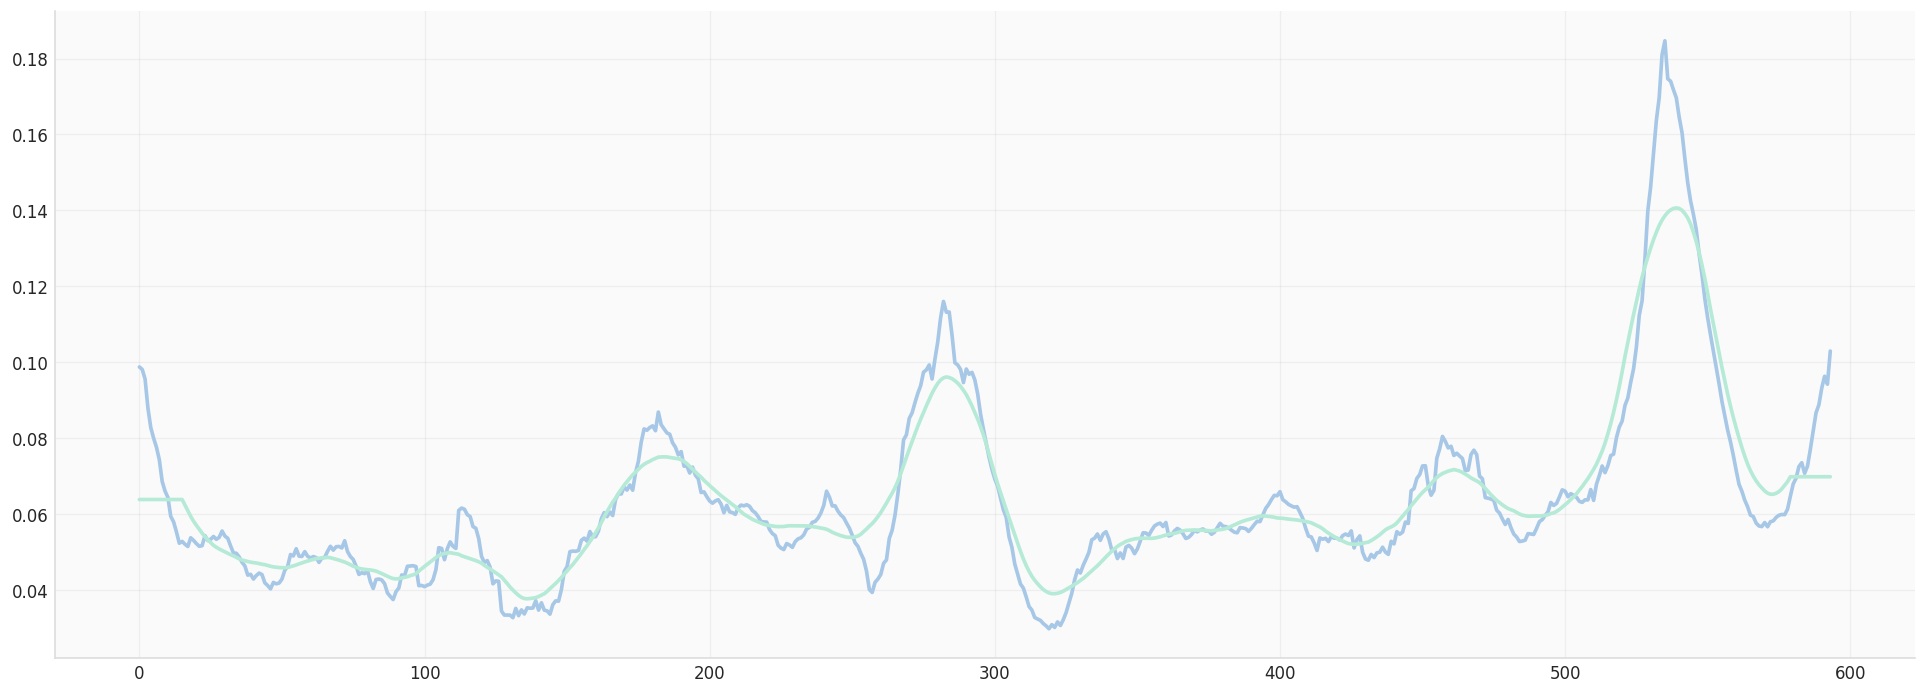

In [905]:
plt.plot(betas)
betas_smooth = pd.Series(betas).rolling(30, center=True).mean()
betas_smooth = betas_smooth.fillna(method='bfill').fillna(method='ffill')
plt.plot(betas_smooth)
None

### <center> Построение SIR- модели <center>

In [906]:
I_model = []
S_model = []
R_model = []

N = 100000


I0 = df.loc[0, 'Инфицированных_на_100к']
R0 = df.loc[0, 'Выздоровлений_на_100к'] + df.loc[0, 'Смертей_на_100к']
S0 = N - I0 - R0

I_model.append(I0)
S_model.append(S0)
R_model.append(R0)

for t in range(len(betas_smooth)):

    beta_t = betas[t]

    I = I_model[-1]
    S = S_model[-1]
    R = R_model[-1]

    I_next = I + beta_t * S * I / N - gamma * I
    S_next = S - beta_t * S * I / N
    R_next = R + gamma * I

    I_model.append(I_next)
    S_model.append(S_next)
    R_model.append(R_next)



I_model = I_model[:len(df)]




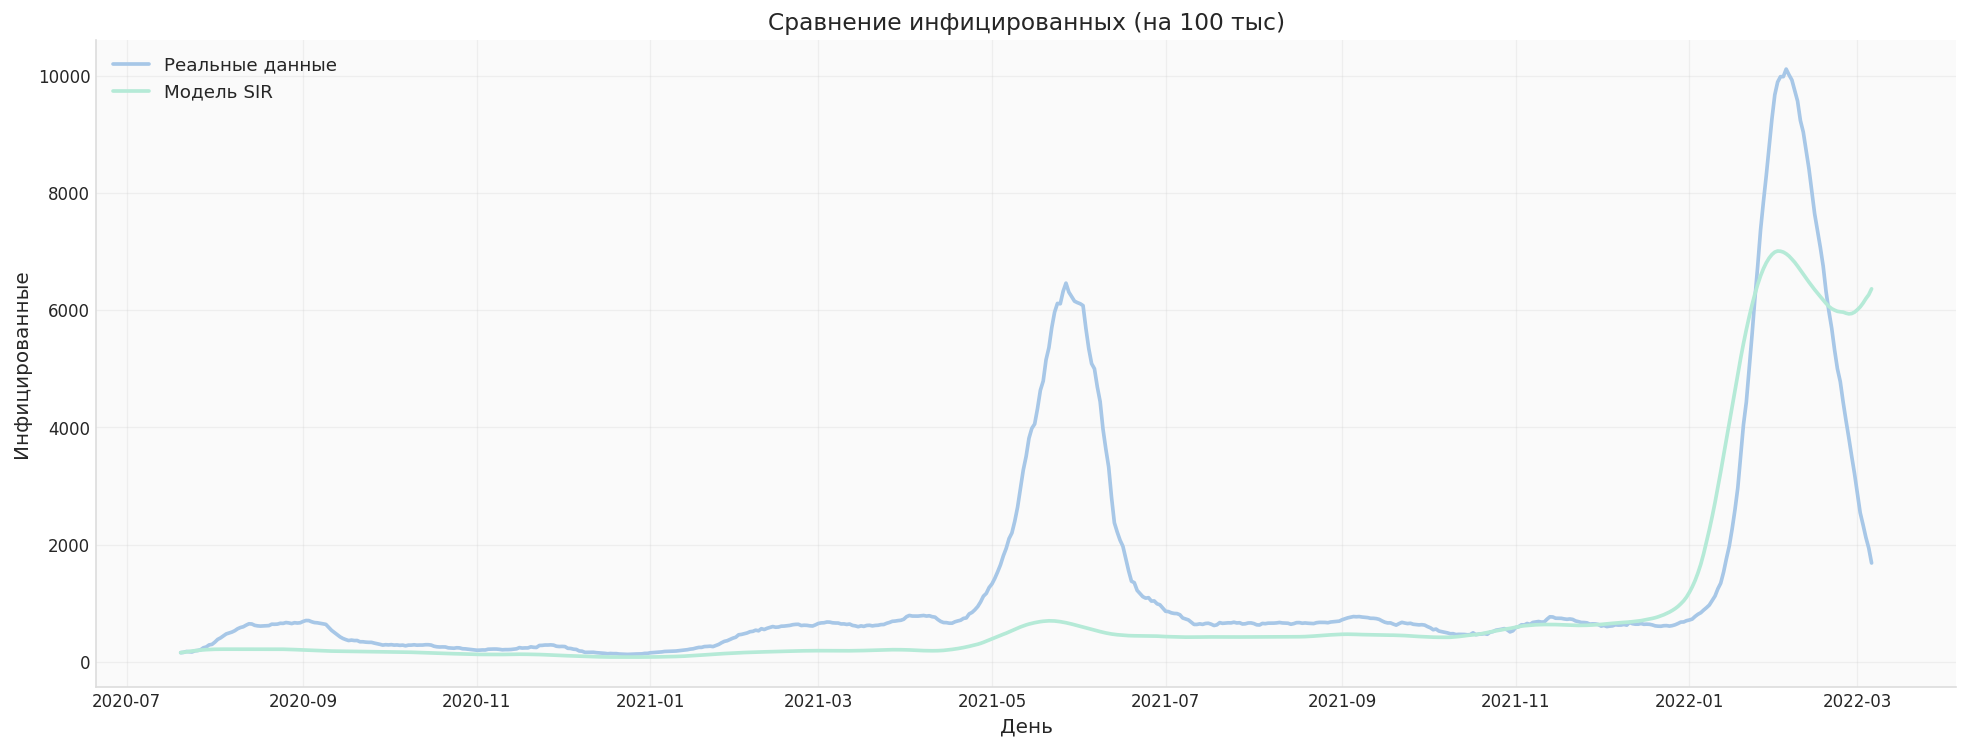

In [907]:
df_plot = df.iloc[:len(I_model)]

plt.figure()


plt.plot(df_plot['Дата'], df_plot['Инфицированных_на_100к'], label='Реальные данные')
plt.plot(df_plot['Дата'], I_model, label='Модель SIR')

plt.title('Сравнение инфицированных (на 100 тыс)')
plt.xlabel('День')
plt.ylabel('Инфицированные')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
mae = np.mean(np.abs(df_plot['Инфицированных_на_100к'].values - I_model))
print("MAE:", mae)

MAE: 670.027551852755


Вывод: SIR-модель достаточно хорошо воспроизводит общую динамику эпидемии и правильно определяет моменты пиков заболеваемости, однако наблюдаются отклонения в их амплитуде. 